In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.model_selection import KFold

data_Tg=pd.read_excel(r'D:\AI4polymer\PA_design\reference\PA_Tg_data_260505.xlsx')

def get_Morgan_fingerprint_frequency(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        info={}
        fp = AllChem.GetMorganFingerprintAsBitVect(mol,3,nBits=2048,bitInfo=info)
        key=[key for key in info.keys()]
        frq=[len(value) for value in info.values()]
        new_info={key: value for key, value in zip(key, frq)}
        mff=[0] * len(list(fp))
        for key, value in new_info.items():
            mff[key] = value
    except:
        mff=None
    return mff

data_Tg['morgan_fp_with_freq'] = data_Tg['SMILES'].apply(get_Morgan_fingerprint_frequency)

[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerator
[14:32:17] DEPRECATION WARNING: please use MorganGenerat

### 1. MFF top

#### 1.1 MFF top MLP

In [2]:
import numpy as np
fingerprints = np.array(data_Tg['morgan_fp_with_freq'].tolist())
nonzero_frequency = np.count_nonzero(fingerprints, axis=0) / fingerprints.shape[0]
nonzero_freq_df = pd.DataFrame({
    'Index': range(len(nonzero_frequency)), 
    'Nonzero_Frequency': nonzero_frequency
})
nonzero_freq_df = nonzero_freq_df.sort_values(by='Nonzero_Frequency', ascending=False)
#top_indices = np.argsort(nonzero_frequency)[-117:]
top_indices = np.argsort(nonzero_frequency)[-100:]
fingerprints_top = fingerprints[:, top_indices]
data_Tg['morgan_fp_top'] = fingerprints_top.tolist()

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ------- 准备数据（含 NaN 安全处理）-------
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# ------- 划分 90%/10% -------
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# ------- 定义模型（MLP + 标准化）-------
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64,32), 
        activation="relu",
        solver="adam",
        alpha=1e-4,               # L2 正则
        batch_size=256,
        learning_rate="adaptive",
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True, 
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# ------- 在 90% 训练集上做 5 折交叉验证 -------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    mlp_model.fit(X_tr, y_tr)
    y_pred_va = mlp_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (MLP) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# ------- 用全部 90% 训练集重新训练，并预测 10% 测试集 -------
mlp_model.fit(X_train, y_train)
y_pred_test = mlp_model.predict(X_test)

MFF_mlp_test_mse  = mean_squared_error(y_test, y_pred_test)
MFF_mlp_test_r2   = r2_score(y_test, y_pred_test)
MFF_mlp_test_mae  = mean_absolute_error(y_test, y_pred_test)
MFF_mlp_test_rmse = np.sqrt(MFF_mlp_test_mse)

print("\n===== Held-out 10% Test (MLP) =====")
print(f"MSE : {MFF_mlp_test_mse:.4f}")
print(f"R2  : {MFF_mlp_test_r2:.4f}")
print(f"MAE : {MFF_mlp_test_mae:.4f}")
print(f"RMSE: {MFF_mlp_test_rmse:.4f}")

print(f"Mean related error (MAE/mean(y_test)): {MFF_mlp_test_mae / np.mean(y_test):.4f}")

# （可选）看 early stopping 实际迭代轮数（最后一次 fit 的）
print("Best iteration (early stopping):", mlp_model.named_steps["mlp"].n_iter_)


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


===== 5-Fold CV on 90% Train (MLP) =====
MSE : 1602.4894 ± 239.1449
R2  : 0.8325 ± 0.0255
MAE : 27.1373 ± 1.8855
RMSE: 39.9139 ± 3.0614

===== Held-out 10% Test (MLP) =====
MSE : 1157.7248
R2  : 0.8726
MAE : 24.2607
RMSE: 34.0254
Mean related error (MAE/mean(y_test)): 0.1307
Best iteration (early stopping): 500


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [7]:
### 调参
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================
# 1. 准备数据
# =========================
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# =========================
# 2. 划分 90% / 10%
# =========================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================
# 3. 定义基础模型
#    只调4个参数，其余固定
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# =========================
# 4. 定义参数网格
# =========================
param_grid = {
    "mlp__hidden_layer_sizes": [
        (64, 32),
        (64, 8)
    ],
    "mlp__alpha": [1e-4, 1e-2],
    "mlp__learning_rate_init": [1e-5, 1e-3],
    "mlp__batch_size": [256, 512]
}

# =========================
# 5. 5-fold CV grid search
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",         # 以CV R2最高选最优参数
    cv=kf,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

# =========================
# 6. 输出最优参数
# =========================
print("===== Best Parameters from 5-Fold CV =====")
print(grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

# =========================
# 7. 提取最优参数对应的CV结果
# =========================
cv_results = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_

best_cv_r2 = cv_results.loc[best_idx, "mean_test_score"]
best_cv_r2_std = cv_results.loc[best_idx, "std_test_score"]

print("\n===== 5-Fold CV Performance of Best Params =====")
print(f"R2: {best_cv_r2:.4f} ± {best_cv_r2_std:.4f}")

# =========================
# 8. 用最优参数在全部90%训练集上重训
# =========================
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# =========================
# 9. 在10%测试集上评估
# =========================
y_pred_test = best_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print("\n===== Held-out 10% Test Performance =====")
print(f"MSE : {test_mse:.4f}")
print(f"R2  : {test_r2:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {test_mae / np.mean(y_test):.4f}")

print("\nBest iteration (early stopping):", best_model.named_steps["mlp"].n_iter_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


===== Best Parameters from 5-Fold CV =====
{'mlp__alpha': 0.0001, 'mlp__batch_size': 256, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.001}
Best CV R2: 0.8325

===== 5-Fold CV Performance of Best Params =====
R2: 0.8325 ± 0.0255

===== Held-out 10% Test Performance =====
MSE : 1157.7248
R2  : 0.8726
MAE : 24.2607
RMSE: 34.0254
Mean related error (MAE/mean(y_test)): 0.1307

Best iteration (early stopping): 500


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
def get_morgan_fp_top(fingerprints):
    fingerprints_top = fingerprints[:, top_indices]
    return fingerprints_top

def get_predicted_Tg(smi):
    try:
        mff=get_Morgan_fingerprint_frequency(smi)
        mff_top=get_morgan_fp_top(np.array([mff], dtype=float))
        predicted_Tg = mlp_model.predict(mff_top)
        predicted_Tg=predicted_Tg[0]
    except:
        predicted_Tg=None
    return predicted_Tg

data_selected_MD=pd.read_excel(r'D:\AI4polymer\PA_design\Inverse Model\novel_design_2600506\MD_summary_260526.xlsx')
data_selected_MD['ML_predicted_Tg']=data_selected_MD['SMILES'].apply(get_predicted_Tg)
data_selected_MD

[14:37:50] DEPRECATION WARNING: please use MorganGenerator
[14:37:50] DEPRECATION WARNING: please use MorganGenerator
[14:37:50] DEPRECATION WARNING: please use MorganGenerator
[14:37:50] DEPRECATION WARNING: please use MorganGenerator


,ID,SMILES,ML_Tg/℃,ML_Tg/K,MD_Tg,related error,ML_predicted_Tg
0,PA01,*c1ccc(cc1)Oc1ccc2c3c1cccc3c1n(c2=O)c2c(n1)ccc...,431.665395,704.815395,778.6,NaN,431.665395
1,PA02,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)NC(=O)c1ccc(...,466.566914,739.716914,774.8,NaN,466.566914
2,PA03,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)Oc1ccc(cc1)O...,463.828501,736.978501,722.8,NaN,463.828501
3,PA04,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)Oc1ccc(cc1)C...,441.732337,714.882337,723.1,NaN,441.732337


In [7]:
data_selected_MD['ML_predicted_Tg_K']=data_selected_MD['ML_predicted_Tg']+273.15
data_selected_MD['relative_error']=abs(data_selected_MD['ML_predicted_Tg_K']-data_selected_MD['MD_Tg'])/data_selected_MD['MD_Tg']
data_selected_MD

,ID,SMILES,ML_Tg/℃,ML_Tg/K,MD_Tg,related error,ML_predicted_Tg,ML_predicted_Tg_K,relative_error
0,PA01,*c1ccc(cc1)Oc1ccc2c3c1cccc3c1n(c2=O)c2c(n1)ccc...,431.665395,704.815395,778.6,NaN,431.665395,704.815395,0.094766
1,PA02,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)NC(=O)c1ccc(...,466.566914,739.716914,774.8,NaN,466.566914,739.716914,0.045280
2,PA03,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)Oc1ccc(cc1)O...,463.828501,736.978501,722.8,NaN,463.828501,736.978501,0.019616
3,PA04,*c1ccc2c(c1)C(=O)N(C2=O)c1ccc(cc1)Oc1ccc(cc1)C...,441.732337,714.882337,723.1,NaN,441.732337,714.882337,0.011364


In [8]:
data_selected_MD['relative_error'].mean()

np.float64(0.04275662293778866)

d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


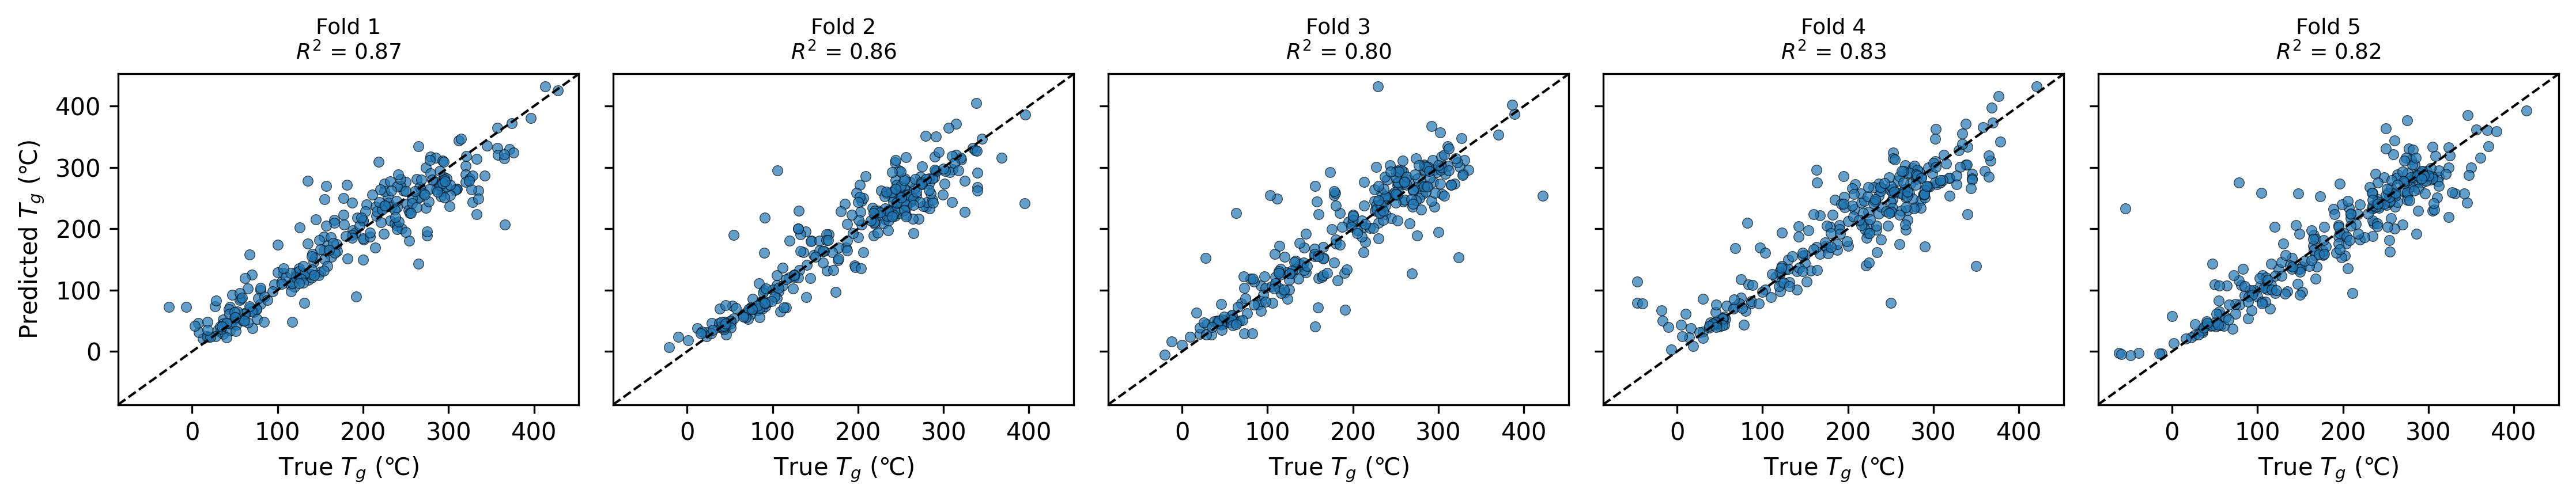

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. 在 CV 中保存每一折预测结果
# ===============================
cv_results = []  # 存每一折 (y_true, y_pred)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), start=1):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    mlp_model.fit(X_tr, y_tr)
    y_pred_va = mlp_model.predict(X_va)

    cv_results.append((y_va, y_pred_va))

# ===============================
# 2. 统一坐标范围（保证五折可比）
# ===============================
all_y = np.concatenate([y for y, _ in cv_results])
y_min, y_max = all_y.min(), all_y.max()
padding = 0.05 * (y_max - y_min)
lims = (y_min - padding, y_max + padding)

# ===============================
# 3. 1 行 5 列作图
# ===============================
fig, axes = plt.subplots(1, 5, figsize=(15, 3), dpi=300, sharex=True, sharey=True)

for i, ax in enumerate(axes):
    y_true, y_pred = cv_results[i]

    ax.scatter(
        y_true, y_pred,
        s=18,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.3
    )

    # 1:1 reference line
    ax.plot(lims, lims, '--', color='black', linewidth=1)

    r2 = r2_score(y_true, y_pred)

    ax.set_title(f"Fold {i+1}\n$R^2$ = {r2:.2f}", fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    if i == 0:
        ax.set_ylabel("Predicted $T_g$ (℃)", fontsize=10)
    ax.set_xlabel("True $T_g$ (℃)", fontsize=10)

# ===============================
# 4. 整体排版
# ===============================
plt.tight_layout()
plt.show()


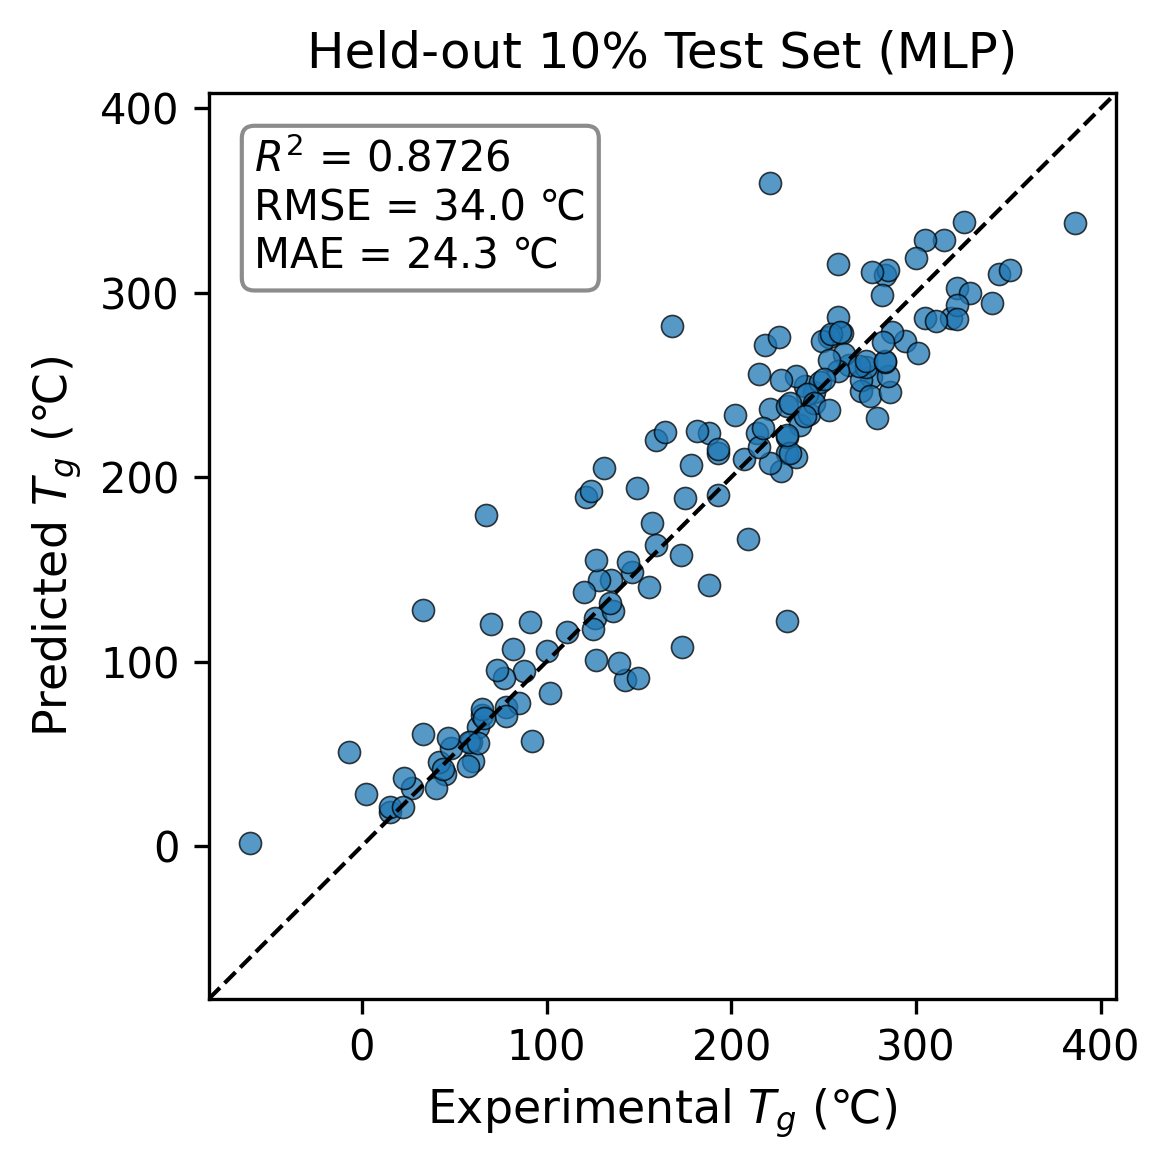

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ===============================
# 1. 计算指标
# ===============================
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

# ===============================
# 2. 统一坐标范围
# ===============================
y_min = min(y_test.min(), y_pred_test.min())
y_max = max(y_test.max(), y_pred_test.max())
pad = 0.05 * (y_max - y_min)
lims = (y_min - pad, y_max + pad)

# ===============================
# 3. 作图
# ===============================
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

ax.scatter(
    y_test, y_pred_test,
    s=28,
    alpha=0.75,
    edgecolor="k",
    linewidth=0.4
)

# 1:1 参考线
ax.plot(lims, lims, '--', color='black', linewidth=1)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Experimental $T_g$ (℃)", fontsize=11)
ax.set_ylabel("Predicted $T_g$ (℃)", fontsize=11)

# 指标标注
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.4f}\nRMSE = {rmse:.1f} ℃\nMAE = {mae:.1f} ℃",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
)

ax.set_title("Held-out 10% Test Set (MLP)", fontsize=12)

plt.tight_layout()
plt.show()


#### 1.2 MFF top RF

In [27]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ------- 准备数据（含 NaN 安全处理）-------
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# ------- 划分 90%/10% -------
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# ------- 定义模型（随机森林）-------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# ------- 在 90% 训练集上做 5 折交叉验证 -------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    rf_model.fit(X_tr, y_tr)
    y_pred_va = rf_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (Random Forest) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# ------- 用全部 90% 训练集重新训练，并预测 10% 测试集 -------
rf_model.fit(X_train, y_train)
y_pred_test = rf_model.predict(X_test)

MFF_rf_test_mse  = mean_squared_error(y_test, y_pred_test)
MFF_rf_test_r2   = r2_score(y_test, y_pred_test)
MFF_rf_test_mae  = mean_absolute_error(y_test, y_pred_test)
MFF_rf_test_rmse = np.sqrt(MFF_rf_test_mse)

print("\n===== Held-out 10% Test (Random Forest) =====")
print(f"MSE : {MFF_rf_test_mse:.4f}")
print(f"R2  : {MFF_rf_test_r2:.4f}")
print(f"MAE : {MFF_rf_test_mae:.4f}")
print(f"RMSE: {MFF_rf_test_rmse:.4f}")

print(f"Mean related error (MAE/mean(y_test)): {MFF_rf_test_mae / np.mean(y_test):.4f}")

===== 5-Fold CV on 90% Train (Random Forest) =====
MSE : 1272.1628 ± 194.8326
R2  : 0.8664 ± 0.0228
MAE : 23.2015 ± 1.6498
RMSE: 35.5545 ± 2.8356

===== Held-out 10% Test (Random Forest) =====
MSE : 1064.1711
R2  : 0.8829
MAE : 22.0975
RMSE: 32.6216
Mean related error (MAE/mean(y_test)): 0.1190


In [36]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备数据
# =========================================================
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100,200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (RF) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_rf_model.predict(X_test)

test_mse  = mean_squared_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print("\n===== Held-out 10% Test (Best Random Forest) =====")
print(f"MSE : {test_mse:.4f}")
print(f"R2  : {test_r2:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X_train shape: (1366, 100)
X_test shape: (152, 100)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

===== Best Grid Search Result (RF) =====
Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.8664

===== Held-out 10% Test (Best Random Forest) =====
MSE : 1064.1711
R2  : 0.8829
MAE : 22.0975
RMSE: 32.6216
Mean related error (MAE/mean(y_test)): 0.1190

===== Top Grid Search Results =====
                                                params  mean_test_score  \
37   {'max_depth': None, 'max_features': None, 'min...         0.866401   
199  {'max_depth': 30, 'max_features': None, 'min_s...         0.866369   
145  {'max_depth': 20, 'max_features': None, 'min_s...         0.866312   
198  {'max_depth': 30, 'max_features': None, 'min_s...         0.865730   
36   {'max_depth': None, 'max_features': None, 'min...         0.865688   
163  {'max_depth': 30, 'max_features': 'sqrt', 'min...    

#### 1.3 MFF top XGBoost

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ------- 准备数据（含 NaN 安全处理）-------
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# ------- 划分 90%/10% -------
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# ------- 定义模型（XGBoost）-------
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ------- 在 90% 训练集上做 5 折交叉验证 -------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    xgb_model.fit(X_tr, y_tr)
    y_pred_va = xgb_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (XGBoost) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# ------- 用全部 90% 训练集重新训练，并预测 10% 测试集 -------
xgb_model.fit(X_train, y_train)
y_pred_test = xgb_model.predict(X_test)

MFF_xgb_test_mse  = mean_squared_error(y_test, y_pred_test)
MFF_xgb_test_r2   = r2_score(y_test, y_pred_test)
MFF_xgb_test_mae  = mean_absolute_error(y_test, y_pred_test)
MFF_xgb_test_rmse = np.sqrt(MFF_xgb_test_mse)

print("\n===== Held-out 10% Test (XGBoost) =====")
print(f"MSE : {MFF_xgb_test_mse:.4f}")
print(f"R2  : {MFF_xgb_test_r2:.4f}")
print(f"MAE : {MFF_xgb_test_mae:.4f}")
print(f"RMSE: {MFF_xgb_test_rmse:.4f}")

print(f"Mean related error (MAE/mean(y_test)): {MFF_xgb_test_mae / np.mean(y_test):.4f}")

===== 5-Fold CV on 90% Train (XGBoost) =====
MSE : 1176.3167 ± 188.1428
R2  : 0.8765 ± 0.0216
MAE : 22.0624 ± 1.6932
RMSE: 34.1786 ± 2.8536

===== Held-out 10% Test (XGBoost) =====
MSE : 1005.8734
R2  : 0.8893
MAE : 21.2011
RMSE: 31.7155
Mean related error (MAE/mean(y_test)): 0.1142


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# 1. 准备数据
# =========================================================
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20, 30],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (XGBoost) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_xgb_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_xgb_model.predict(X_test)

test_mse  = mean_squared_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print("\n===== Held-out 10% Test (Best XGBoost) =====")
print(f"MSE : {test_mse:.4f}")
print(f"R2  : {test_r2:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X_train shape: (1366, 100)
X_test shape: (152, 100)
Fitting 5 folds for each of 96 candidates, totalling 480 fits

===== Best Grid Search Result (XGBoost) =====
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2: 0.8781

===== Held-out 10% Test (Best XGBoost) =====
MSE : 1127.9999
R2  : 0.8759
MAE : 21.6510
RMSE: 33.5857
Mean related error (MAE/mean(y_test)): 0.1166

===== Top Grid Search Results =====
                                               params  mean_test_score  \
22  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.878128   
82  {'colsample_bytree': 1.0, 'learning_rate': 0.1...         0.876353   
70  {'colsample_bytree': 1.0, 'learning_rate': 0.0...         0.876348   
20  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.875402   
38  {'colsample_bytree': 0.8, 'learning_rate': 0.1...         0.874798   
36  {'colsample_bytree': 0.8, 'learning_rate': 0.1...         0.874688  

#### 1.4 MFF top LASSO

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ------- 准备数据（含 NaN 安全处理）-------
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# ------- 划分 90%/10% -------
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# ------- 定义模型（LASSO + 标准化）-------
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=0.1,
        max_iter=5000,
        tol=1e-4,
        random_state=42
    ))
])

# ------- 在 90% 训练集上做 5 折交叉验证 -------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    lasso_model.fit(X_tr, y_tr)
    y_pred_va = lasso_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (LASSO) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# ------- 用全部 90% 训练集重新训练，并预测 10% 测试集 -------
lasso_model.fit(X_train, y_train)
y_pred_test = lasso_model.predict(X_test)

MFF_lasso_test_mse  = mean_squared_error(y_test, y_pred_test)
MFF_lasso_test_r2   = r2_score(y_test, y_pred_test)
MFF_lasso_test_mae  = mean_absolute_error(y_test, y_pred_test)
MFF_lasso_test_rmse = np.sqrt(MFF_lasso_test_mse)

print("\n===== Held-out 10% Test (LASSO) =====")
print(f"MSE : {MFF_lasso_test_mse:.4f}")
print(f"R2  : {MFF_lasso_test_r2:.4f}")
print(f"MAE : {MFF_lasso_test_mae:.4f}")
print(f"RMSE: {MFF_lasso_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MFF_lasso_test_mae / np.mean(y_test):.4f}")

# 看最终保留下来的非零系数个数
coef = lasso_model.named_steps["lasso"].coef_
n_nonzero = np.sum(coef != 0)
print("Number of non-zero coefficients:", n_nonzero)

===== 5-Fold CV on 90% Train (LASSO) =====
MSE : 2226.2978 ± 288.3291
R2  : 0.7676 ± 0.0265
MAE : 34.8493 ± 2.5129
RMSE: 47.0876 ± 3.0100

===== Held-out 10% Test (LASSO) =====
MSE : 2273.6847
R2  : 0.7498
MAE : 36.0972
RMSE: 47.6832
Mean related error (MAE/mean(y_test)): 0.1944
Number of non-zero coefficients: 88


In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备数据
# =========================================================
X = np.array(data_Tg['morgan_fp_top'].tolist(), dtype=float)
y = data_Tg['Tg_mean'].values.astype(float)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        random_state=42,
        tol=1e-4
    ))
])

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "lasso__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
    "lasso__max_iter": [5000, 10000, 20000]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (LASSO) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_lasso_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_lasso_model.predict(X_test)

test_mse  = mean_squared_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print("\n===== Held-out 10% Test (Best LASSO) =====")
print(f"MSE : {test_mse:.4f}")
print(f"R2  : {test_r2:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X_train shape: (1366, 100)
X_test shape: (152, 100)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== Best Grid Search Result (LASSO) =====
Best params: {'lasso__alpha': 0.1, 'lasso__max_iter': 5000}
Best CV R2: 0.7676

===== Held-out 10% Test (Best LASSO) =====
MSE : 2273.6847
R2  : 0.7498
MAE : 36.0972
RMSE: 47.6832
Mean related error (MAE/mean(y_test)): 0.1944

===== Top Grid Search Results =====
                                               params  mean_test_score  \
10    {'lasso__alpha': 0.1, 'lasso__max_iter': 10000}         0.767552   
11    {'lasso__alpha': 0.1, 'lasso__max_iter': 20000}         0.767552   
9      {'lasso__alpha': 0.1, 'lasso__max_iter': 5000}         0.767552   
6     {'lasso__alpha': 0.01, 'lasso__max_iter': 5000}         0.761003   
8    {'lasso__alpha': 0.01, 'lasso__max_iter': 20000}         0.760996   
7    {'lasso__alpha': 0.01, 'lasso__max_iter': 10000}         0.760996   
3    {'lasso__alpha': 0.001, 'lasso__max_iter': 5000}        

### 2. PolyNC

In [30]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
tokenizer = AutoTokenizer.from_pretrained("hkqiu/PolyNC")
model = AutoModelForSeq2SeqLM.from_pretrained("hkqiu/PolyNC")
def get_polync_embedding(psmiles):
    inputs = tokenizer(psmiles, return_tensors="pt")
    with torch.no_grad():
        encoder_outputs = model.get_encoder()(**inputs)
    token_embeddings = encoder_outputs.last_hidden_state
    embedding = token_embeddings.mean(dim=1).squeeze().cpu().numpy()
    return embedding

data_Tg["polync_embedding"] = data_Tg["SMILES"].apply(get_polync_embedding)

# =========================================================
# 4. 去掉 embedding 或 Tg 缺失的样本
# =========================================================
data_Tg_model = data_Tg.dropna(subset=["polync_embedding", "Tg_mean"]).reset_index(drop=True)

valid_mask = data_Tg_model["polync_embedding"].apply(
    lambda x: isinstance(x, np.ndarray) and x.ndim == 1 and len(x) > 0
)
data_Tg_model = data_Tg_model[valid_mask].reset_index(drop=True)

#### 2.1 PolyNC MLP

In [31]:
# =========================================================
# 5. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 6. 划分 90%/10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 7. 定义模型（MLP + 标准化）
# =========================================================
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-2,
        batch_size=256,
        learning_rate="adaptive",
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# =========================================================
# 8. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    mlp_model.fit(X_tr, y_tr)
    y_pred_va = mlp_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (PolyNC + MLP) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 9. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
mlp_model.fit(X_train, y_train)
y_pred_test = mlp_model.predict(X_test)

PolyNC_mlp_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_mlp_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_mlp_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_mlp_test_rmse = np.sqrt(PolyNC_mlp_test_mse)

print("\n===== Held-out 10% Test (PolyNC + MLP) =====")
print(f"MSE : {PolyNC_mlp_test_mse:.4f}")
print(f"R2  : {PolyNC_mlp_test_r2:.4f}")
print(f"MAE : {PolyNC_mlp_test_mae:.4f}")
print(f"RMSE: {PolyNC_mlp_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_mlp_test_mae / np.mean(y_test):.4f}")

print("Best iteration (early stopping):", mlp_model.named_steps["mlp"].n_iter_)

X shape: (1518, 768)
y shape: (1518,)
===== 5-Fold CV on 90% Train (PolyNC + MLP) =====
MSE : 1372.7037 ± 197.6342
R2  : 0.8556 ± 0.0250
MAE : 24.3263 ± 1.3529
RMSE: 36.9496 ± 2.7264

===== Held-out 10% Test (PolyNC + MLP) =====
MSE : 1318.4347
R2  : 0.8549
MAE : 25.5007
RMSE: 36.3103
Mean related error (MAE/mean(y_test)): 0.1373
Best iteration (early stopping): 146


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 去掉 embedding 或 Tg 缺失的样本
# =========================================================
data_Tg_model = data_Tg.dropna(subset=["polync_embedding", "Tg_mean"]).reset_index(drop=True)

valid_mask = data_Tg_model["polync_embedding"].apply(
    lambda x: isinstance(x, np.ndarray) and x.ndim == 1 and len(x) > 0
)
data_Tg_model = data_Tg_model[valid_mask].reset_index(drop=True)

# =========================================================
# 2. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 3. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 4. 定义基础模型
# =========================================================
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# =========================================================
# 5. 定义参数网格
# =========================================================
param_grid = {
    "mlp__hidden_layer_sizes": [
        (64, 32),
        (64, 8)
    ],
    "mlp__alpha": [1e-4, 1e-2],
    "mlp__learning_rate_init": [1e-5, 1e-3],
    "mlp__batch_size": [256, 512]
}

# =========================================================
# 6. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 7. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (PolyNC + MLP) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# =========================================================
# 8. 在 10% test 上评估
# =========================================================
y_pred_test = best_model.predict(X_test)

PolyNC_mlp_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_mlp_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_mlp_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_mlp_test_rmse = np.sqrt(PolyNC_mlp_test_mse)

print("\n===== Held-out 10% Test (Best PolyNC + MLP) =====")
print(f"MSE : {PolyNC_mlp_test_mse:.4f}")
print(f"R2  : {PolyNC_mlp_test_r2:.4f}")
print(f"MAE : {PolyNC_mlp_test_mae:.4f}")
print(f"RMSE: {PolyNC_mlp_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_mlp_test_mae / np.mean(y_test):.4f}")

print("Best iteration (early stopping):", best_model.named_steps["mlp"].n_iter_)

# =========================================================
# 9. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 768)
y shape: (1518,)
X_train shape: (1366, 768)
X_test shape: (152, 768)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Best Grid Search Result (PolyNC + MLP) =====
Best params: {'mlp__alpha': 0.01, 'mlp__batch_size': 256, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.001}
Best CV R2: 0.8556

===== Held-out 10% Test (Best PolyNC + MLP) =====
MSE : 1318.4347
R2  : 0.8549
MAE : 25.5007
RMSE: 36.3103
Mean related error (MAE/mean(y_test)): 0.1373
Best iteration (early stopping): 146

===== Top Grid Search Results =====
                                               params  mean_test_score  \
9   {'mlp__alpha': 0.01, 'mlp__batch_size': 256, '...         0.855646   
1   {'mlp__alpha': 0.0001, 'mlp__batch_size': 256,...         0.854980   
13  {'mlp__alpha': 0.01, 'mlp__batch_size': 512, '...         0.850689   
5   {'mlp__alpha': 0.0001, 'mlp__batch_size': 512,...         0.850468   
3   {'mlp__alpha': 0.0001, 'mlp__batch_size': 256,.

#### 2.2 PolyNC RF

In [32]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 3. 定义模型（PolyNC + Random Forest）
# =========================================================
#'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    rf_model.fit(X_tr, y_tr)
    y_pred_va = rf_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (PolyNC + Random Forest) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 5. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
rf_model.fit(X_train, y_train)
y_pred_test = rf_model.predict(X_test)

PolyNC_rf_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_rf_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_rf_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_rf_test_rmse = np.sqrt(PolyNC_rf_test_mse)

print("\n===== Held-out 10% Test (PolyNC + Random Forest) =====")
print(f"MSE : {PolyNC_rf_test_mse:.4f}")
print(f"R2  : {PolyNC_rf_test_r2:.4f}")
print(f"MAE : {PolyNC_rf_test_mae:.4f}")
print(f"RMSE: {PolyNC_rf_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_rf_test_mae / np.mean(y_test):.4f}")

X shape: (1518, 768)
y shape: (1518,)
===== 5-Fold CV on 90% Train (PolyNC + Random Forest) =====
MSE : 1356.4493 ± 223.2858
R2  : 0.8583 ± 0.0215
MAE : 25.2368 ± 1.9919
RMSE: 36.7046 ± 3.0372

===== Held-out 10% Test (PolyNC + Random Forest) =====
MSE : 1262.0947
R2  : 0.8611
MAE : 24.9616
RMSE: 35.5260
Mean related error (MAE/mean(y_test)): 0.1344


In [14]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (PolyNC + Random Forest) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_rf_model.predict(X_test)

PolyNC_rf_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_rf_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_rf_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_rf_test_rmse = np.sqrt(PolyNC_rf_test_mse)

print("\n===== Held-out 10% Test (Best PolyNC + Random Forest) =====")
print(f"MSE : {PolyNC_rf_test_mse:.4f}")
print(f"R2  : {PolyNC_rf_test_r2:.4f}")
print(f"MAE : {PolyNC_rf_test_mae:.4f}")
print(f"RMSE: {PolyNC_rf_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_rf_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 768)
y shape: (1518,)
X_train shape: (1366, 768)
X_test shape: (152, 768)
Fitting 5 folds for each of 162 candidates, totalling 810 fits

===== Best Grid Search Result (PolyNC + Random Forest) =====
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.8583

===== Held-out 10% Test (Best PolyNC + Random Forest) =====
MSE : 1262.0947
R2  : 0.8611
MAE : 24.9616
RMSE: 35.5260
Mean related error (MAE/mean(y_test)): 0.1344

===== Top Grid Search Results =====
                                                params  mean_test_score  \
1    {'max_depth': None, 'max_features': 'sqrt', 'm...         0.858289   
109  {'max_depth': 20, 'max_features': 'sqrt', 'min...         0.857116   
43   {'max_depth': None, 'max_features': None, 'min...         0.856993   
151  {'max_depth': 20, 'max_features': None, 'min_s...         0.856947   
0    {'max_depth': None, 'max_features': 'sqrt', 'm...         0.

#### 2.3 PolyNC XGBoost

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 3. 定义模型（PolyNC + XGBoost）
# =========================================================
#{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    xgb_model.fit(X_tr, y_tr)
    y_pred_va = xgb_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (PolyNC + XGBoost) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 5. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
xgb_model.fit(X_train, y_train)
y_pred_test = xgb_model.predict(X_test)

PolyNC_xgb_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_xgb_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_xgb_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_xgb_test_rmse = np.sqrt(PolyNC_xgb_test_mse)

print("\n===== Held-out 10% Test (PolyNC + XGBoost) =====")
print(f"MSE : {PolyNC_xgb_test_mse:.4f}")
print(f"R2  : {PolyNC_xgb_test_r2:.4f}")
print(f"MAE : {PolyNC_xgb_test_mae:.4f}")
print(f"RMSE: {PolyNC_xgb_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_xgb_test_mae / np.mean(y_test):.4f}")

X shape: (1518, 768)
y shape: (1518,)
===== 5-Fold CV on 90% Train (PolyNC + XGBoost) =====
MSE : 1311.5051 ± 232.9470
R2  : 0.8626 ± 0.0250
MAE : 23.4728 ± 1.7621
RMSE: 36.0668 ± 3.2699

===== Held-out 10% Test (PolyNC + XGBoost) =====
MSE : 1092.5184
R2  : 0.8798
MAE : 23.6858
RMSE: 33.0533
Mean related error (MAE/mean(y_test)): 0.1276


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    #"max_depth": [3, 5, 7],
    "max_depth": [None, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (PolyNC + XGBoost) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_xgb_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_xgb_model.predict(X_test)

PolyNC_xgb_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_xgb_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_xgb_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_xgb_test_rmse = np.sqrt(PolyNC_xgb_test_mse)

print("\n===== Held-out 10% Test (Best PolyNC + XGBoost) =====")
print(f"MSE : {PolyNC_xgb_test_mse:.4f}")
print(f"R2  : {PolyNC_xgb_test_r2:.4f}")
print(f"MAE : {PolyNC_xgb_test_mae:.4f}")
print(f"RMSE: {PolyNC_xgb_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_xgb_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 768)
y shape: (1518,)
X_train shape: (1366, 768)
X_test shape: (152, 768)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

===== Best Grid Search Result (PolyNC + XGBoost) =====
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': None, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2: 0.8762

===== Held-out 10% Test (Best PolyNC + XGBoost) =====
MSE : 1017.5271
R2  : 0.8880
MAE : 22.0997
RMSE: 31.8987
Mean related error (MAE/mean(y_test)): 0.1190

===== Top Grid Search Results =====
                                               params  mean_test_score  \
34  {'colsample_bytree': 1.0, 'learning_rate': 0.0...         0.876181   
10  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.873019   
38  {'colsample_bytree': 1.0, 'learning_rate': 0.0...         0.872672   
14  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.870880   
36  {'colsample_bytree': 1.0, 'learning_rate': 0.0...         0.870656   
32  {'colsampl

#### 2.4 PolyNC LASSO

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 3. 定义模型（PolyNC + LASSO）
# =========================================================
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=0.1,
        max_iter=20000,
        tol=1e-4,
        random_state=42
    ))
])

# =========================================================
# 4. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    lasso_model.fit(X_tr, y_tr)
    y_pred_va = lasso_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (PolyNC + LASSO) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 5. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
lasso_model.fit(X_train, y_train)
y_pred_test = lasso_model.predict(X_test)

PolyNC_lasso_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_lasso_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_lasso_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_lasso_test_rmse = np.sqrt(PolyNC_lasso_test_mse)

print("\n===== Held-out 10% Test (PolyNC + LASSO) =====")
print(f"MSE : {PolyNC_lasso_test_mse:.4f}")
print(f"R2  : {PolyNC_lasso_test_r2:.4f}")
print(f"MAE : {PolyNC_lasso_test_mae:.4f}")
print(f"RMSE: {PolyNC_lasso_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_lasso_test_mae / np.mean(y_test):.4f}")

# 非零系数个数
coef = lasso_model.named_steps["lasso"].coef_
n_nonzero = np.sum(coef != 0)
print("Number of non-zero coefficients:", n_nonzero)

X shape: (1518, 768)
y shape: (1518,)


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.667e+04, tolerance: 1.028e+03
  model = cd_fast.enet_coordinate_descent(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.901e+03, tolerance: 1.077e+03
  model = cd_fast.enet_coordinate_descent(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.275e+03, toleranc

===== 5-Fold CV on 90% Train (PolyNC + LASSO) =====
MSE : 1511.9984 ± 183.3225
R2  : 0.8415 ± 0.0220
MAE : 25.8415 ± 1.5179
RMSE: 38.8105 ± 2.3960

===== Held-out 10% Test (PolyNC + LASSO) =====
MSE : 1337.7182
R2  : 0.8528
MAE : 26.6424
RMSE: 36.5748
Mean related error (MAE/mean(y_test)): 0.1435
Number of non-zero coefficients: 312


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.235e+04, tolerance: 1.313e+03
  model = cd_fast.enet_coordinate_descent(


In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["polync_embedding"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 2. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 3. 定义基础模型
# =========================================================
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        random_state=42,
        tol=1e-4
    ))
])

# =========================================================
# 4. 定义参数网格
# =========================================================
param_grid = {
    "lasso__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
    "lasso__max_iter": [5000, 10000, 20000]
}

# =========================================================
# 5. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 6. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (PolyNC + LASSO) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_lasso_model = grid_search.best_estimator_

# =========================================================
# 7. 在 10% test 上评估
# =========================================================
y_pred_test = best_lasso_model.predict(X_test)

PolyNC_lasso_test_mse  = mean_squared_error(y_test, y_pred_test)
PolyNC_lasso_test_r2   = r2_score(y_test, y_pred_test)
PolyNC_lasso_test_mae  = mean_absolute_error(y_test, y_pred_test)
PolyNC_lasso_test_rmse = np.sqrt(PolyNC_lasso_test_mse)

print("\n===== Held-out 10% Test (Best PolyNC + LASSO) =====")
print(f"MSE : {PolyNC_lasso_test_mse:.4f}")
print(f"R2  : {PolyNC_lasso_test_r2:.4f}")
print(f"MAE : {PolyNC_lasso_test_mae:.4f}")
print(f"RMSE: {PolyNC_lasso_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {PolyNC_lasso_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 8. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

# =========================================================
# 9. 查看最佳模型非零系数个数
# =========================================================
coef = best_lasso_model.named_steps["lasso"].coef_
n_nonzero = np.sum(coef != 0)
print("Number of non-zero coefficients:", n_nonzero)

X shape: (1518, 768)
y shape: (1518,)
X_train shape: (1366, 768)
X_test shape: (152, 768)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== Best Grid Search Result (PolyNC + LASSO) =====
Best params: {'lasso__alpha': 0.1, 'lasso__max_iter': 20000}
Best CV R2: 0.8415

===== Held-out 10% Test (Best PolyNC + LASSO) =====
MSE : 1337.7182
R2  : 0.8528
MAE : 26.6424
RMSE: 36.5748
Mean related error (MAE/mean(y_test)): 0.1435

===== Top Grid Search Results =====
                                              params  mean_test_score  \
11   {'lasso__alpha': 0.1, 'lasso__max_iter': 20000}         0.841487   
10   {'lasso__alpha': 0.1, 'lasso__max_iter': 10000}         0.841477   
9     {'lasso__alpha': 0.1, 'lasso__max_iter': 5000}         0.840996   
12    {'lasso__alpha': 1.0, 'lasso__max_iter': 5000}         0.825174   
13   {'lasso__alpha': 1.0, 'lasso__max_iter': 10000}         0.825174   
14   {'lasso__alpha': 1.0, 'lasso__max_iter': 20000}         0.825174   
15   {'lass

d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.235e+04, tolerance: 1.313e+03
  model = cd_fast.enet_coordinate_descent(


### 3. MACCS

In [35]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys

from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 定义 MACCS 指纹函数
# =========================================================
def get_maccs_fp(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        fp = MACCSkeys.GenMACCSKeys(mol)
        arr = np.array(list(fp), dtype=float)
        return arr
    except:
        return None

# =========================================================
# 2. 生成 MACCS 指纹
# 假设结构列名为 "SMILES"
# =========================================================
data_Tg = data_Tg.copy()
data_Tg["maccs_fp"] = data_Tg["SMILES"].apply(get_maccs_fp)

#### 3.1 MACCS MLP

In [36]:
# =========================================================
# 3. 去掉 MACCS 或 Tg 缺失的样本
# =========================================================
data_Tg_model = data_Tg.dropna(subset=["maccs_fp", "Tg_mean"]).reset_index(drop=True)

valid_mask = data_Tg_model["maccs_fp"].apply(
    lambda x: isinstance(x, np.ndarray) and x.ndim == 1 and len(x) > 0
)
data_Tg_model = data_Tg_model[valid_mask].reset_index(drop=True)

# =========================================================
# 4. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 5. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 6. 定义模型（MACCS + MLP）
# =========================================================
# Best params: {'mlp__alpha': 0.0001, 'mlp__batch_size': 256, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.001}
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate="adaptive",
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# =========================================================
# 7. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    mlp_model.fit(X_tr, y_tr)
    y_pred_va = mlp_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (MACCS + MLP) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 8. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
mlp_model.fit(X_train, y_train)
y_pred_test = mlp_model.predict(X_test)

MACCS_mlp_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_mlp_test_r2   = r2_score(y_test, y_pred_test)
MACCS_mlp_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_mlp_test_rmse = np.sqrt(MACCS_mlp_test_mse)

print("\n===== Held-out 10% Test (MACCS + MLP) =====")
print(f"MSE : {MACCS_mlp_test_mse:.4f}")
print(f"R2  : {MACCS_mlp_test_r2:.4f}")
print(f"MAE : {MACCS_mlp_test_mae:.4f}")
print(f"RMSE: {MACCS_mlp_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_mlp_test_mae / np.mean(y_test):.4f}")

print("Best iteration (early stopping):", mlp_model.named_steps["mlp"].n_iter_)

X shape: (1518, 167)
y shape: (1518,)


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


===== 5-Fold CV on 90% Train (MACCS + MLP) =====
MSE : 1598.9340 ± 160.7608
R2  : 0.8323 ± 0.0208
MAE : 27.3391 ± 1.0809
RMSE: 39.9347 ± 2.0376

===== Held-out 10% Test (MACCS + MLP) =====
MSE : 1290.5167
R2  : 0.8580
MAE : 25.4509
RMSE: 35.9238
Mean related error (MAE/mean(y_test)): 0.1371
Best iteration (early stopping): 384


In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================================================
# 1. 去掉 MACCS 或 Tg 缺失的样本
# =========================================================
data_Tg_model = data_Tg.dropna(subset=["maccs_fp", "Tg_mean"]).reset_index(drop=True)

valid_mask = data_Tg_model["maccs_fp"].apply(
    lambda x: isinstance(x, np.ndarray) and x.ndim == 1 and len(x) > 0
)
data_Tg_model = data_Tg_model[valid_mask].reset_index(drop=True)

# =========================================================
# 2. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 3. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 4. 定义基础模型
# =========================================================
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=False
    ))
])

# =========================================================
# 5. 定义参数网格
# =========================================================
param_grid = {
    "mlp__hidden_layer_sizes": [
        (64, 32),
        (64, 8)
    ],
    "mlp__alpha": [1e-4, 1e-2],
    "mlp__learning_rate_init": [1e-5, 1e-3],
    "mlp__batch_size": [256, 512]
}

# =========================================================
# 6. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 7. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (MACCS + MLP) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# =========================================================
# 8. 在 10% test 上评估
# =========================================================
y_pred_test = best_model.predict(X_test)

MACCS_mlp_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_mlp_test_r2   = r2_score(y_test, y_pred_test)
MACCS_mlp_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_mlp_test_rmse = np.sqrt(MACCS_mlp_test_mse)

print("\n===== Held-out 10% Test (Best MACCS + MLP) =====")
print(f"MSE : {MACCS_mlp_test_mse:.4f}")
print(f"R2  : {MACCS_mlp_test_r2:.4f}")
print(f"MAE : {MACCS_mlp_test_mae:.4f}")
print(f"RMSE: {MACCS_mlp_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_mlp_test_mae / np.mean(y_test):.4f}")

print("Best iteration (early stopping):", best_model.named_steps["mlp"].n_iter_)

# =========================================================
# 9. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 167)
y shape: (1518,)
X_train shape: (1366, 167)
X_test shape: (152, 167)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Best Grid Search Result (MACCS + MLP) =====
Best params: {'mlp__alpha': 0.0001, 'mlp__batch_size': 256, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.001}
Best CV R2: 0.8323

===== Held-out 10% Test (Best MACCS + MLP) =====
MSE : 1290.5167
R2  : 0.8580
MAE : 25.4509
RMSE: 35.9238
Mean related error (MAE/mean(y_test)): 0.1371
Best iteration (early stopping): 384

===== Top Grid Search Results =====
                                               params  mean_test_score  \
1   {'mlp__alpha': 0.0001, 'mlp__batch_size': 256,...         0.832315   
9   {'mlp__alpha': 0.01, 'mlp__batch_size': 256, '...         0.831583   
13  {'mlp__alpha': 0.01, 'mlp__batch_size': 512, '...         0.817677   
5   {'mlp__alpha': 0.0001, 'mlp__batch_size': 512,...         0.817608   
3   {'mlp__alpha': 0.0001, 'mlp__batch_size': 256,.

#### 3.2 MACCS RF

In [37]:
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# 4. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 5. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 6. 定义模型（MACCS + Random Forest）
# =========================================================
# {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 7. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    rf_model.fit(X_tr, y_tr)
    y_pred_va = rf_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (MACCS + Random Forest) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 8. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
rf_model.fit(X_train, y_train)
y_pred_test = rf_model.predict(X_test)

MACCS_rf_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_rf_test_r2   = r2_score(y_test, y_pred_test)
MACCS_rf_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_rf_test_rmse = np.sqrt(MACCS_rf_test_mse)

print("\n===== Held-out 10% Test (MACCS + Random Forest) =====")
print(f"MSE : {MACCS_rf_test_mse:.4f}")
print(f"R2  : {MACCS_rf_test_r2:.4f}")
print(f"MAE : {MACCS_rf_test_mae:.4f}")
print(f"RMSE: {MACCS_rf_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_rf_test_mae / np.mean(y_test):.4f}")

X shape: (1518, 167)
y shape: (1518,)
===== 5-Fold CV on 90% Train (MACCS + Random Forest) =====
MSE : 1398.4908 ± 107.5402
R2  : 0.8530 ± 0.0191
MAE : 25.5462 ± 0.6096
RMSE: 37.3678 ± 1.4613

===== Held-out 10% Test (MACCS + Random Forest) =====
MSE : 1344.4292
R2  : 0.8521
MAE : 25.0142
RMSE: 36.6665
Mean related error (MAE/mean(y_test)): 0.1347


In [23]:
# =========================================================
# 2. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 3. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 4. 定义基础模型
# =========================================================
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 5. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

# =========================================================
# 6. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 7. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (MACCS + Random Forest) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# =========================================================
# 8. 在 10% test 上评估
# =========================================================
y_pred_test = best_rf_model.predict(X_test)

MACCS_rf_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_rf_test_r2   = r2_score(y_test, y_pred_test)
MACCS_rf_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_rf_test_rmse = np.sqrt(MACCS_rf_test_mse)

print("\n===== Held-out 10% Test (Best MACCS + Random Forest) =====")
print(f"MSE : {MACCS_rf_test_mse:.4f}")
print(f"R2  : {MACCS_rf_test_r2:.4f}")
print(f"MAE : {MACCS_rf_test_mae:.4f}")
print(f"RMSE: {MACCS_rf_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_rf_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 9. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 167)
y shape: (1518,)
X_train shape: (1366, 167)
X_test shape: (152, 167)
Fitting 5 folds for each of 162 candidates, totalling 810 fits

===== Best Grid Search Result (MACCS + Random Forest) =====
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.8530

===== Held-out 10% Test (Best MACCS + Random Forest) =====
MSE : 1344.4292
R2  : 0.8521
MAE : 25.0142
RMSE: 36.6665
Mean related error (MAE/mean(y_test)): 0.1347

===== Top Grid Search Results =====
                                                params  mean_test_score  \
109  {'max_depth': 20, 'max_features': 'sqrt', 'min...         0.852954   
108  {'max_depth': 20, 'max_features': 'sqrt', 'min...         0.852889   
127  {'max_depth': 20, 'max_features': 'log2', 'min...         0.852799   
1    {'max_depth': None, 'max_features': 'sqrt', 'm...         0.851291   
0    {'max_depth': None, 'max_features': 'sqrt', 'm...         0.8512

#### 3.3 MACCS XGBoost

In [38]:
from xgboost import XGBRegressor
# =========================================================
# 4. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 5. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 6. 定义模型（MACCS + XGBoost）
# =========================================================
# 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 100, 'subsample': 0.8
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=None,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# =========================================================
# 7. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    xgb_model.fit(X_tr, y_tr)
    y_pred_va = xgb_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (MACCS + XGBoost) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 8. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
xgb_model.fit(X_train, y_train)
y_pred_test = xgb_model.predict(X_test)

MACCS_xgb_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_xgb_test_r2   = r2_score(y_test, y_pred_test)
MACCS_xgb_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_xgb_test_rmse = np.sqrt(MACCS_xgb_test_mse)

print("\n===== Held-out 10% Test (MACCS + XGBoost) =====")
print(f"MSE : {MACCS_xgb_test_mse:.4f}")
print(f"R2  : {MACCS_xgb_test_r2:.4f}")
print(f"MAE : {MACCS_xgb_test_mae:.4f}")
print(f"RMSE: {MACCS_xgb_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_xgb_test_mae / np.mean(y_test):.4f}")

X shape: (1518, 167)
y shape: (1518,)
===== 5-Fold CV on 90% Train (MACCS + XGBoost) =====
MSE : 1338.2458 ± 149.8332
R2  : 0.8592 ± 0.0217
MAE : 25.0415 ± 1.1966
RMSE: 36.5229 ± 2.0797

===== Held-out 10% Test (MACCS + XGBoost) =====
MSE : 1229.0901
R2  : 0.8647
MAE : 25.1639
RMSE: 35.0584
Mean related error (MAE/mean(y_test)): 0.1355


In [19]:
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 3. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 4. 定义基础模型
# 建议 n_jobs=1，把并行留给 GridSearchCV，更稳定
# =========================================================
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

# =========================================================
# 5. 定义参数网格
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# =========================================================
# 6. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 7. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (MACCS + XGBoost) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_xgb_model = grid_search.best_estimator_

# =========================================================
# 8. 在 10% test 上评估
# =========================================================
y_pred_test = best_xgb_model.predict(X_test)

MACCS_xgb_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_xgb_test_r2   = r2_score(y_test, y_pred_test)
MACCS_xgb_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_xgb_test_rmse = np.sqrt(MACCS_xgb_test_mse)

print("\n===== Held-out 10% Test (Best MACCS + XGBoost) =====")
print(f"MSE : {MACCS_xgb_test_mse:.4f}")
print(f"R2  : {MACCS_xgb_test_r2:.4f}")
print(f"MAE : {MACCS_xgb_test_mae:.4f}")
print(f"RMSE: {MACCS_xgb_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_xgb_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 9. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

X shape: (1518, 167)
y shape: (1518,)
X_train shape: (1366, 167)
X_test shape: (152, 167)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

===== Best Grid Search Result (MACCS + XGBoost) =====
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 100, 'subsample': 0.8}
Best CV R2: 0.8609

===== Held-out 10% Test (Best MACCS + XGBoost) =====
MSE : 1317.0692
R2  : 0.8551
MAE : 25.3425
RMSE: 36.2914
Mean related error (MAE/mean(y_test)): 0.1365

===== Top Grid Search Results =====
                                               params  mean_test_score  \
16  {'colsample_bytree': 0.8, 'learning_rate': 0.1...         0.860860   
34  {'colsample_bytree': 1.0, 'learning_rate': 0.0...         0.860709   
10  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.859848   
40  {'colsample_bytree': 1.0, 'learning_rate': 0.1...         0.859743   
11  {'colsample_bytree': 0.8, 'learning_rate': 0.0...         0.857619   
18  {'colsample_b

#### 3.4 MACCS LASSO

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso


# =========================================================
# 4. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 5. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

# =========================================================
# 6. 定义模型（MACCS + LASSO）
# =========================================================
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=0.1,
        max_iter=5000,
        tol=1e-4,
        random_state=42
    ))
])

# =========================================================
# 7. 在 90% 训练集上做 5 折交叉验证
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse, cv_r2, cv_mae, cv_rmse = [], [], [], []

for tr_idx, va_idx in kf.split(X_train):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    lasso_model.fit(X_tr, y_tr)
    y_pred_va = lasso_model.predict(X_va)

    mse = mean_squared_error(y_va, y_pred_va)
    cv_mse.append(mse)
    cv_r2.append(r2_score(y_va, y_pred_va))
    cv_mae.append(mean_absolute_error(y_va, y_pred_va))
    cv_rmse.append(np.sqrt(mse))

print("===== 5-Fold CV on 90% Train (MACCS + LASSO) =====")
print(f"MSE : {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"R2  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")

# =========================================================
# 8. 用全部 90% 训练集重新训练，并预测 10% 测试集
# =========================================================
lasso_model.fit(X_train, y_train)
y_pred_test = lasso_model.predict(X_test)

MACCS_lasso_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_lasso_test_r2   = r2_score(y_test, y_pred_test)
MACCS_lasso_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_lasso_test_rmse = np.sqrt(MACCS_lasso_test_mse)

print("\n===== Held-out 10% Test (MACCS + LASSO) =====")
print(f"MSE : {MACCS_lasso_test_mse:.4f}")
print(f"R2  : {MACCS_lasso_test_r2:.4f}")
print(f"MAE : {MACCS_lasso_test_mae:.4f}")
print(f"RMSE: {MACCS_lasso_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_lasso_test_mae / np.mean(y_test):.4f}")

# 非零系数个数
coef = lasso_model.named_steps["lasso"].coef_
n_nonzero = np.sum(coef != 0)
print("Number of non-zero coefficients:", n_nonzero)

X shape: (1518, 167)
y shape: (1518,)
===== 5-Fold CV on 90% Train (MACCS + LASSO) =====
MSE : 2198.8899 ± 148.0034
R2  : 0.7699 ± 0.0184
MAE : 34.4324 ± 1.8144
RMSE: 46.8664 ± 1.5593

===== Held-out 10% Test (MACCS + LASSO) =====
MSE : 1995.5711
R2  : 0.7804
MAE : 32.8243
RMSE: 44.6718
Mean related error (MAE/mean(y_test)): 0.1768
Number of non-zero coefficients: 121


In [27]:
# =========================================================
# 2. 准备 X, y
# =========================================================
X = np.vstack(data_Tg_model["maccs_fp"].values).astype(float)
y = data_Tg_model["Tg_mean"].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# 3. 划分 90% / 10%
# =========================================================
RANDOM_STATE_SPLIT = 282
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE_SPLIT, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 4. 定义基础模型
# =========================================================
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        random_state=42,
        tol=1e-4
    ))
])

# =========================================================
# 5. 定义参数网格
# =========================================================
param_grid = {
    "lasso__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
    "lasso__max_iter": [5000, 10000, 20000]
}

# =========================================================
# 6. Grid Search（只在 90% train 上做 5-fold）
# =========================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# =========================================================
# 7. 输出最优参数和CV结果
# =========================================================
print("\n===== Best Grid Search Result (MACCS + LASSO) =====")
print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")

best_lasso_model = grid_search.best_estimator_

# =========================================================
# 8. 在 10% test 上评估
# =========================================================
y_pred_test = best_lasso_model.predict(X_test)

MACCS_lasso_test_mse  = mean_squared_error(y_test, y_pred_test)
MACCS_lasso_test_r2   = r2_score(y_test, y_pred_test)
MACCS_lasso_test_mae  = mean_absolute_error(y_test, y_pred_test)
MACCS_lasso_test_rmse = np.sqrt(MACCS_lasso_test_mse)

print("\n===== Held-out 10% Test (Best MACCS + LASSO) =====")
print(f"MSE : {MACCS_lasso_test_mse:.4f}")
print(f"R2  : {MACCS_lasso_test_r2:.4f}")
print(f"MAE : {MACCS_lasso_test_mae:.4f}")
print(f"RMSE: {MACCS_lasso_test_rmse:.4f}")
print(f"Mean related error (MAE/mean(y_test)): {MACCS_lasso_test_mae / np.mean(y_test):.4f}")

# =========================================================
# 9. 保存所有 grid search 结果
# =========================================================
df_grid_results = pd.DataFrame(grid_search.cv_results_)

df_grid_results = df_grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score",
    "std_train_score"
]].sort_values("rank_test_score")

print("\n===== Top Grid Search Results =====")
print(df_grid_results.head(10))

# =========================================================
# 10. 查看最佳模型非零系数个数
# =========================================================
coef = best_lasso_model.named_steps["lasso"].coef_
n_nonzero = np.sum(coef != 0)
print("Number of non-zero coefficients:", n_nonzero)

X shape: (1518, 167)
y shape: (1518,)
X_train shape: (1366, 167)
X_test shape: (152, 167)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== Best Grid Search Result (MACCS + LASSO) =====
Best params: {'lasso__alpha': 0.1, 'lasso__max_iter': 5000}
Best CV R2: 0.7699

===== Held-out 10% Test (Best MACCS + LASSO) =====
MSE : 1995.5711
R2  : 0.7804
MAE : 32.8243
RMSE: 44.6718
Mean related error (MAE/mean(y_test)): 0.1768

===== Top Grid Search Results =====
                                               params  mean_test_score  \
10    {'lasso__alpha': 0.1, 'lasso__max_iter': 10000}         0.769882   
11    {'lasso__alpha': 0.1, 'lasso__max_iter': 20000}         0.769882   
9      {'lasso__alpha': 0.1, 'lasso__max_iter': 5000}         0.769882   
12     {'lasso__alpha': 1.0, 'lasso__max_iter': 5000}         0.765865   
13    {'lasso__alpha': 1.0, 'lasso__max_iter': 10000}         0.765865   
14    {'lasso__alpha': 1.0, 'lasso__max_iter': 20000}         0.765865   
6     {

### 4. Draw

In [40]:
import pandas as pd
import numpy as np

# =========================================================
# 1. 定义 embedding 和 model
# =========================================================
embeddings = ["MFF", "PolyNC", "MACCS"]
models = ["MLP", "RF", "XGB", "LASSO"]

# =========================================================
# 2. 定义一个安全读取变量的函数
#    如果变量不存在，则填 NaN，并打印提醒
# =========================================================
def safe_get(var_name):
    if var_name in globals():
        return globals()[var_name]
    else:
        print(f"Warning: {var_name} not found, set as NaN")
        return np.nan

# =========================================================
# 3. 汇总结果
# =========================================================
records = []

for emb in embeddings:
    for model in models:
        model_lower = model.lower()

        r2_var   = f"{emb}_{model_lower}_test_r2"
        mae_var  = f"{emb}_{model_lower}_test_mae"
        rmse_var = f"{emb}_{model_lower}_test_rmse"

        records.append({
            "Embedding": emb,
            "Model": model,
            "R2": safe_get(r2_var),
            "MAE": safe_get(mae_var),
            "RMSE": safe_get(rmse_var)
        })

df_results = pd.DataFrame(records)

# 可选：按 embedding 和 model 排序
df_results["Embedding"] = pd.Categorical(df_results["Embedding"], categories=embeddings, ordered=True)
df_results["Model"] = pd.Categorical(df_results["Model"], categories=models, ordered=True)
df_results = df_results.sort_values(["Embedding", "Model"]).reset_index(drop=True)

print(df_results)

   Embedding  Model        R2        MAE       RMSE
0        MFF    MLP  0.872599  24.260679  34.025356
1        MFF     RF  0.882894  22.097518  32.621636
2        MFF    XGB  0.889310  21.201062  31.715507
3        MFF  LASSO  0.749795  36.097159  47.683170
4     PolyNC    MLP  0.854914  25.500684  36.310257
5     PolyNC     RF  0.861114  24.961641  35.525972
6     PolyNC    XGB  0.879775  23.685765  33.053266
7     PolyNC  LASSO  0.852792  26.642432  36.574830
8      MACCS    MLP  0.857987  25.450856  35.923762
9      MACCS     RF  0.852054  25.014183  36.666459
10     MACCS    XGB  0.864746  25.163920  35.058382
11     MACCS  LASSO  0.780400  32.824264  44.671816


In [ ]:
#df_results.to_csv("QSPR_results_summary_260506.csv", index=False)